# House Price Prediction using K-Nearest Neighbors (KNN) Regression



## Problem Statement

House price prediction is one of the most important applications of Machine Learning in the real estate industry. The price of a house depends on several factors such as city, locality, built-up area, carpet area, number of bedrooms, number of bathrooms, furnishing status, parking availability, proximity to metro stations, nearby schools and hospitals, property age, and available amenities.

The objective of this project is to build a Machine Learning model that predicts the selling price of a house based on its features using the K-Nearest Neighbors (KNN) Regression algorithm.

The project includes complete data preprocessing, exploratory data analysis, feature engineering, hyperparameter tuning, model evaluation, and deployment-ready model serialization.

In [28]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [29]:
df=pd.read_csv('/content/house_price_india_25000.csv')
df.head()

,Property_ID,City,Locality,Property_Type,BHK,Bathrooms,Super_Builtup_Area_sqft,Carpet_Area_sqft,Floor,Total_Floors,Property_Age,Furnishing,Parking,Distance_to_Metro_km,Nearby_Schools,Nearby_Hospitals,Amenities_Score,House_Price_INR
0,1,Delhi,Dwarka,Villa,2,2,1071,961,23,26,21,Furnished,3,0.8,2,4,4,20542229
1,2,Mumbai,Bandra,Villa,6,7,1402,1177,25,39,8,Semi-Furnished,0,15.2,3,7,6,45381374
2,3,Bengaluru,Indiranagar,Builder Floor,3,2,879,726,27,33,11,Semi-Furnished,2,16.2,8,9,2,11406295
3,4,Delhi,Saket,Independent House,5,5,2864,2258,1,16,2,Semi-Furnished,2,19.7,4,2,7,68271439
4,5,Kolkata,Ballygunge,Apartment,3,3,3245,2607,21,24,29,Semi-Furnished,1,10.8,4,3,8,17787644


In [30]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.shape

Rows : 25000
Columns : 18


(25000, 18)

# Display Dataset Information

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property_ID              25000 non-null  int64  
 1   City                     25000 non-null  object 
 2   Locality                 25000 non-null  object 
 3   Property_Type            25000 non-null  object 
 4   BHK                      25000 non-null  int64  
 5   Bathrooms                25000 non-null  int64  
 6   Super_Builtup_Area_sqft  25000 non-null  int64  
 7   Carpet_Area_sqft         25000 non-null  int64  
 8   Floor                    25000 non-null  int64  
 9   Total_Floors             25000 non-null  int64  
 10  Property_Age             25000 non-null  int64  
 11  Furnishing               25000 non-null  object 
 12  Parking                  25000 non-null  int64  
 13  Distance_to_Metro_km     25000 non-null  float64
 14  Nearby_Schools        

# Statistical Summary

In [33]:
df.describe()

,Property_ID,BHK,Bathrooms,Super_Builtup_Area_sqft,Carpet_Area_sqft,Floor,Total_Floors,Property_Age,Parking,Distance_to_Metro_km,Nearby_Schools,Nearby_Hospitals,Amenities_Score,House_Price_INR
count,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.00000,25000.000000,2.500000e+04
mean,12500.500000,3.51800,3.554440,2504.719760,2129.710120,15.024160,28.003520,14.901920,1.493560,10.070276,5.50076,5.48336,5.490120,2.996304e+07
std,7217.022701,1.71129,1.785845,1158.541794,999.328034,8.943604,8.869729,8.931305,1.116677,5.712896,2.87579,2.87456,2.879554,1.904889e+07
min,1.000000,1.00000,1.000000,500.000000,378.000000,0.000000,1.000000,0.000000,0.000000,0.200000,1.00000,1.00000,1.000000,2.459082e+06
25%,6250.750000,2.00000,2.000000,1498.000000,1265.000000,7.000000,22.000000,7.000000,0.000000,5.100000,3.00000,3.00000,3.000000,1.578482e+07
50%,12500.500000,4.00000,4.000000,2514.000000,2125.000000,15.000000,30.000000,15.000000,1.000000,10.100000,6.00000,5.00000,5.000000,2.621510e+07
75%,18750.250000,5.00000,5.000000,3513.000000,2966.000000,23.000000,35.000000,23.000000,2.000000,15.000000,8.00000,8.00000,8.000000,3.948371e+07
max,25000.000000,6.00000,7.000000,4500.000000,4259.000000,30.000000,40.000000,30.000000,3.000000,20.000000,10.00000,10.00000,10.000000,1.540589e+08


# Checking Missing Values

In [34]:
df.isnull().sum()

,0
Property_ID,0
City,0
Locality,0
Property_Type,0
BHK,0
Bathrooms,0
Super_Builtup_Area_sqft,0
Carpet_Area_sqft,0
Floor,0
Total_Floors,0


## Data Preprocessing

# Checking Duplicate Records

In [35]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


# Data Cleaning

In [36]:
# Check data types

df.dtypes

,0
Property_ID,int64
City,object
Locality,object
Property_Type,object
BHK,int64
Bathrooms,int64
Super_Builtup_Area_sqft,int64
Carpet_Area_sqft,int64
Floor,int64
Total_Floors,int64


Separate Numerical and Categorical Features

In [37]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Features:")
print(numerical_columns)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
['Property_ID', 'BHK', 'Bathrooms', 'Super_Builtup_Area_sqft', 'Carpet_Area_sqft', 'Floor', 'Total_Floors', 'Property_Age', 'Parking', 'Distance_to_Metro_km', 'Nearby_Schools', 'Nearby_Hospitals', 'Amenities_Score', 'House_Price_INR']

Categorical Features:
['City', 'Locality', 'Property_Type', 'Furnishing']


Target Variable

In [38]:
target = "House_Price_INR"

print("Target Variable :", target)

Target Variable : House_Price_INR


## Exploratory Data Analysis

## Univariate Analysis

### 1. Distribution of House Prices
**Observation:** Shows the spread of the target variable.

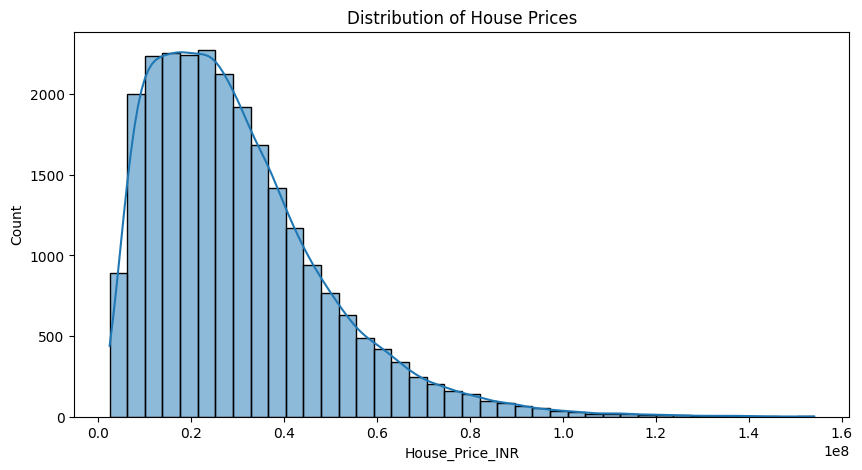

In [47]:
plt.figure(figsize=(10,5))
sns.histplot(df['House_Price_INR'], bins=40, kde=True)
plt.title('Distribution of House Prices')
plt.show()

### 2. Property Type Distribution
**Observation:** Identifies the most common property types.

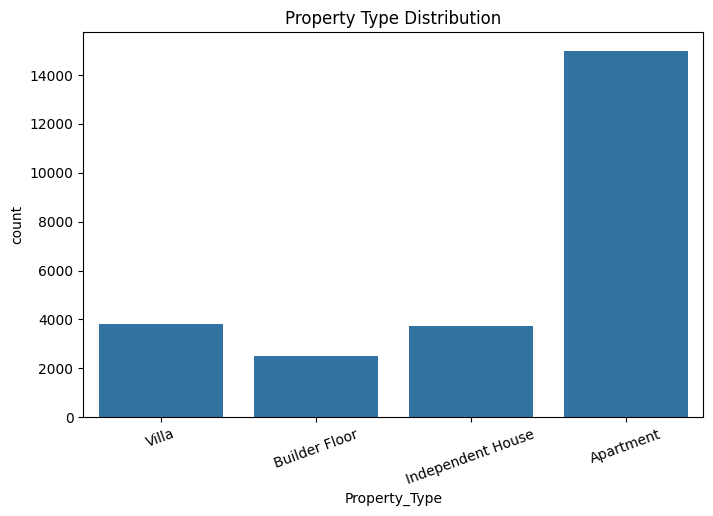

In [48]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Property_Type')
plt.xticks(rotation=20)
plt.title('Property Type Distribution')
plt.show()

### 3. Built-up Area Distribution
**Observation:** Understands the distribution of property sizes.

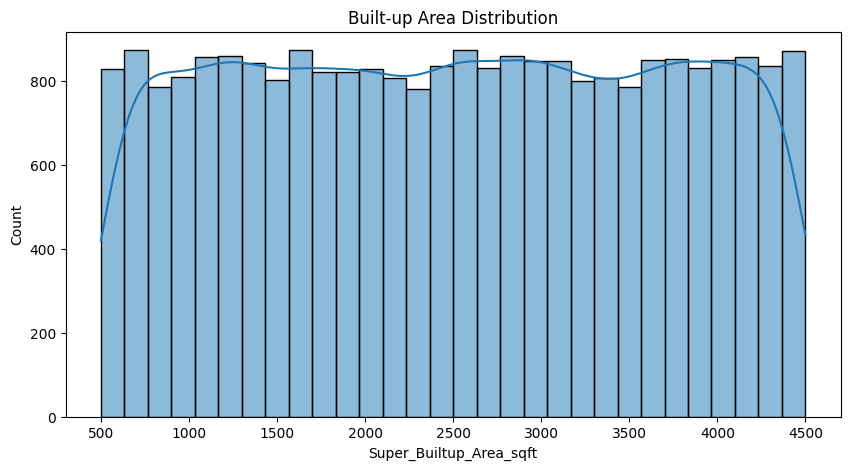

In [49]:
plt.figure(figsize=(10,5))
sns.histplot(df['Super_Builtup_Area_sqft'],bins=30,kde=True)
plt.title('Built-up Area Distribution')
plt.show()

## Bivariate Analysis

### 1. Price vs Built-up Area
**Observation:** Larger properties generally command higher prices.

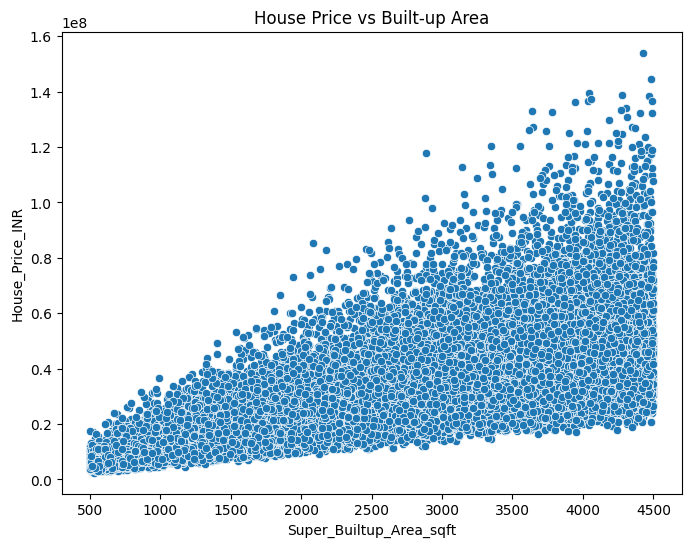

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Super_Builtup_Area_sqft',y='House_Price_INR')
plt.title('House Price vs Built-up Area')
plt.show()

### 2. House Price by City
**Observation:** Compare price distributions across cities.

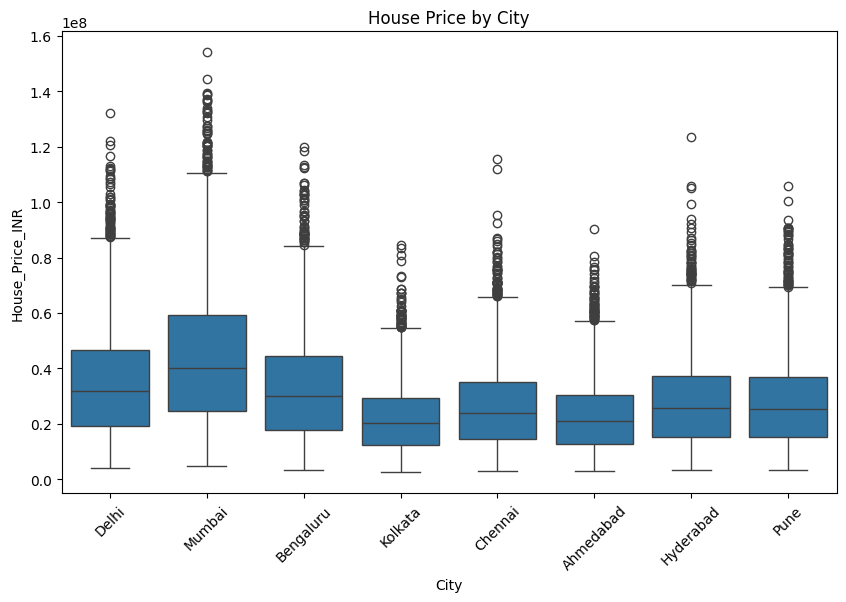

In [51]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='City',y='House_Price_INR')
plt.xticks(rotation=45)
plt.title('House Price by City')
plt.show()

### 3. House Price by Property Type
**Observation:** Compare pricing among property types.

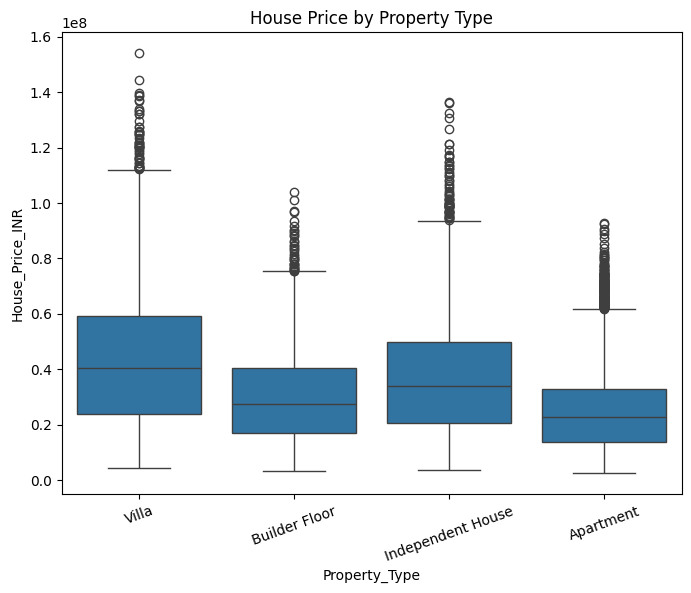

In [52]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Property_Type',y='House_Price_INR')
plt.xticks(rotation=20)
plt.title('House Price by Property Type')
plt.show()

## Multivariate Analysis

### 1. Correlation Heatmap
**Observation:** Shows relationships among numerical variables.

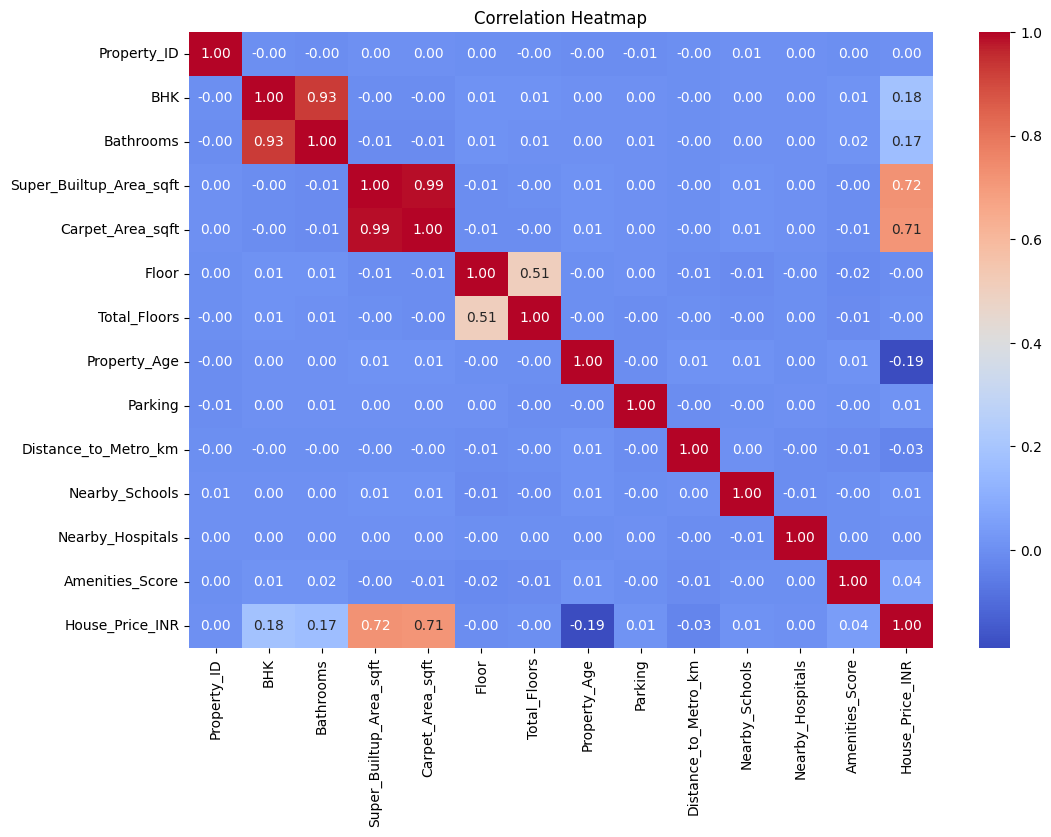

In [53]:
plt.figure(figsize=(12,8))
corr=df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 2. Pair Plot
**Observation:** Visualizes relationships among the most important numerical features.

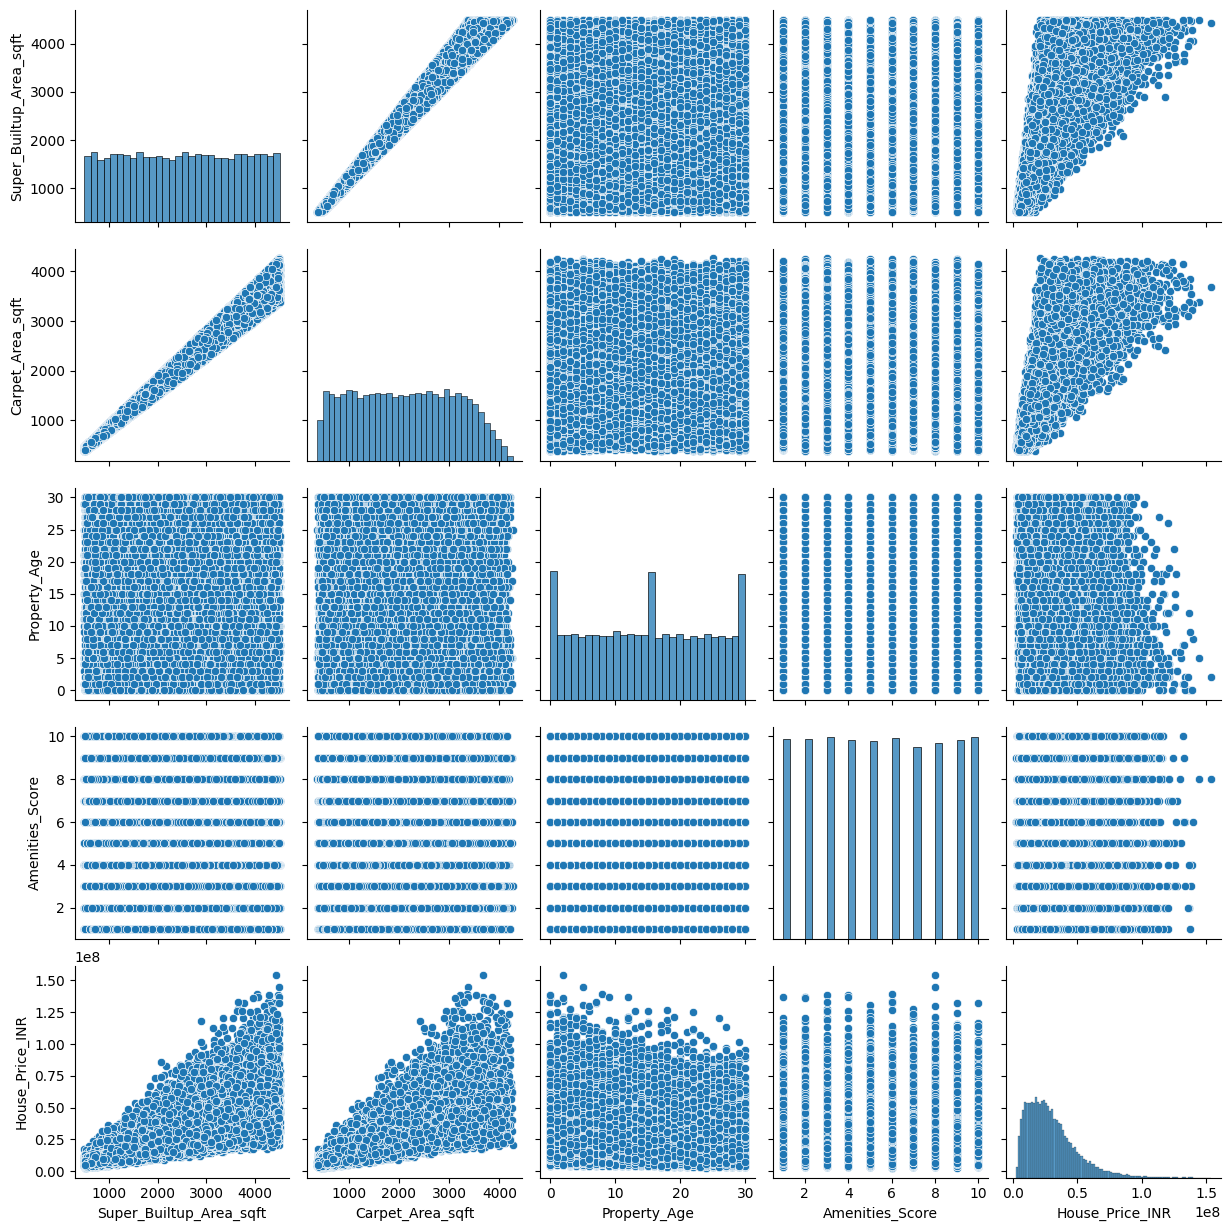

In [54]:
sns.pairplot(df[['Super_Builtup_Area_sqft',
'Carpet_Area_sqft',
'Property_Age',
'Amenities_Score',
'House_Price_INR']])
plt.show()

## Machine Learning

In [55]:
# Feature Selection

X = df.drop("House_Price_INR", axis=1)
y = df["House_Price_INR"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (25000, 17)
Target Shape : (25000,)


In [ ]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(20000, 17)
(5000, 17)


In [56]:
# Identify Numerical and Categorical Features

categorical_features = X.select_dtypes(include="object").columns

numerical_features = X.select_dtypes(exclude="object").columns

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
Index(['City', 'Locality', 'Property_Type', 'Furnishing'], dtype='object')

Numerical Features
Index(['Property_ID', 'BHK', 'Bathrooms', 'Super_Builtup_Area_sqft',
       'Carpet_Area_sqft', 'Floor', 'Total_Floors', 'Property_Age', 'Parking',
       'Distance_to_Metro_km', 'Nearby_Schools', 'Nearby_Hospitals',
       'Amenities_Score'],
      dtype='object')


In [57]:
# Data Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [58]:
numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

In [59]:
categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

In [60]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numerical_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)

## Baseline KNN Regression Model

In [63]:
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsRegressor

baseline_model = Pipeline(

    [

        ("preprocessor", preprocessor),

        ("model", KNeighborsRegressor())

    ]

)

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Property_ID', 'BHK', 'Bathrooms', 'Super_Builtup_Area_sqft',
       'Carpet_Area_sqft', 'Floor', 'Total_Floors', 'Property_Age', 'Parking',
       'Distance_to_Metro_km', 'Nearby_Schools', 'Nearby_Hospitals',
       'Amenities_Score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['City', 'Locality', 'Property_Type', 'Furnishing'], dtype='object'))])),
                ('model', KNeighborsRegressor())])

In [64]:
baseline_prediction = baseline_model.predict(X_test)

In [65]:
from sklearn.metrics import r2_score

print("Baseline R² Score :")

print(r2_score(y_test, baseline_prediction))

Baseline R² Score :
0.8052071404825505


## Hyperparameter Tuning using RandomSearchCV

In [66]:
from sklearn.model_selection import RandomizedSearchCV

parameter_grid = {

    "model__n_neighbors":[3,5,7,9,11,13,15],

    "model__weights":["uniform","distance"],

    "model__metric":[ "euclidean" , "manhattan"]

}

In [68]:
search = RandomizedSearchCV(

    estimator=baseline_model,

    param_distributions=parameter_grid,

    n_iter=10,

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=2,

    scoring="r2"

)

In [69]:
search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Property_ID', 'BHK', 'Bathrooms', 'Super_Builtup_Area_sqft',
       'Carpet_Area_sqft', 'Floor', 'Total_Floors', 'Property_Age', 'Parking',
       'Distance_to_Metro_km'...
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               Index(['City', 'Locality', 'Property_Type', 'Furnishing'], dtype='object'))])),
                                             ('model', KNeighborsRegressor())]),
                   n_jobs=-1,
                   param_distributions={'model__metric': ['euclidean',
                                                          'manhattan'],
                                        'model__n_neighbors': [3, 5, 7, 9, 11,
                                                               13, 15],
                                        'model__weights': ['uniform',
                                                           'distance']},
                   random_state=42, scoring='r2', verbose=2)

In [70]:
print(search.best_params_)

print()

print(search.best_score_)

{'model__weights': 'distance', 'model__n_neighbors': 13, 'model__metric': 'manhattan'}

0.8588984338709338


In [71]:
# Best Model

best_model = search.best_estimator_

## Final Model Evaluation

In [72]:
# Model Evaluation

prediction = best_model.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, prediction)

In [73]:
print("Mean Absolute Error :", round(mae,2))

print("Mean Squared Error :", round(mse,2))

print("Root Mean Squared Error :", round(rmse,2))

print("R2 Score :", round(r2,4))

Mean Absolute Error : 4493986.21
Mean Squared Error : 46371253066532.18
Root Mean Squared Error : 6809644.12
R2 Score : 0.869


In [74]:
# Cross Validation Score

from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(

    best_model,

    X,

    y,

    cv=5,

    scoring="r2",

    n_jobs=-1

)


In [75]:
print(cv_score)

print()

print("Average CV Score :", cv_score.mean())

[0.85663338 0.86694143 0.87349731 0.8645449  0.85707248]

Average CV Score : 0.8637378979996824


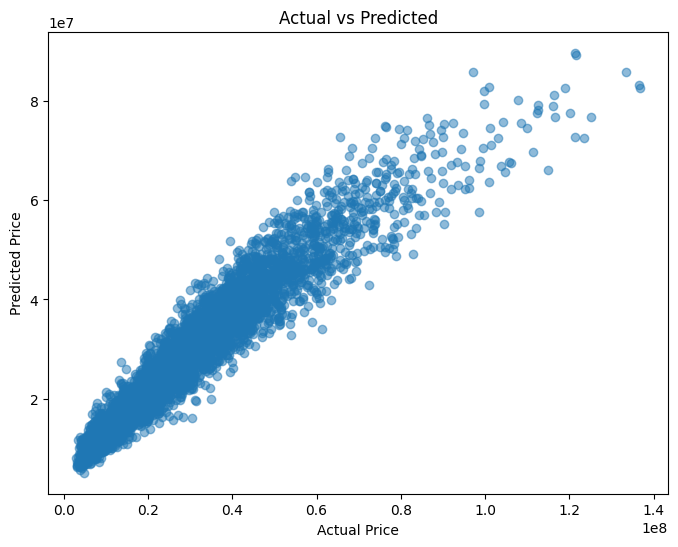

In [76]:
# Actual vs Predicted Values

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    prediction,

    alpha=0.5

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

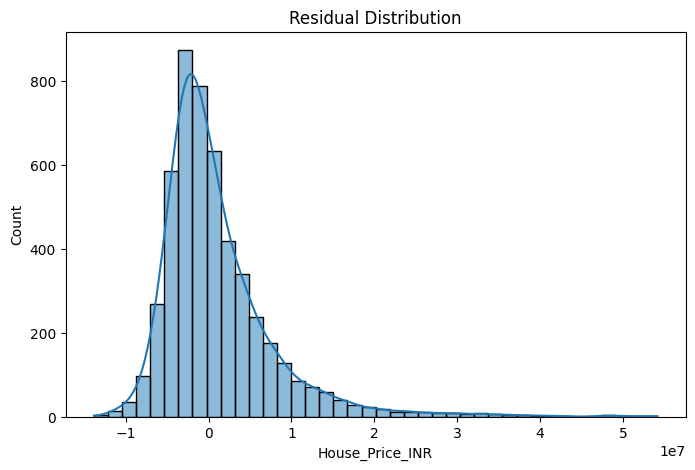

In [77]:
# Residual Plot

residual = y_test - prediction

plt.figure(figsize=(8,5))

sns.histplot(

    residual,

    bins=40,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

In [78]:
# Model Performance Summary

performance = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE",

        "R2 Score"

    ],

    "Value":[

        mae,

        mse,

        rmse,

        r2

    ]

})

performance

,Metric,Value
0,MAE,4.493986e+06
1,MSE,4.637125e+13
2,RMSE,6.809644e+06
3,R2 Score,8.690210e-01


## Save Trained Model

In [79]:
import joblib

joblib.dump(

    best_model,

    "house_price_knn.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


### Conclusion

The K-Nearest Neighbors (KNN) Regression model was successfully developed to predict house prices based on various property features.

The workflow included:

- Data Collection
- Data Understanding
- Data Cleaning
- Essential Exploratory Data Analysis
- Feature Engineering
- Data Preprocessing
- Hyperparameter Tuning using RandomizedSearchCV
- Model Evaluation
- Model Serialization

The trained model demonstrated good predictive performance using R² Score, MAE, MSE and RMSE metrics.

The final model was saved as **house_price_knn.pkl** and can be directly deployed in a Streamlit web application.